In [1]:
# =============================================================================
#
#  Comparative Analysis of Non-Linear Causal Discovery Methods
#
#  This notebook implements and compares three distinct methods for discovering
#  causal structure in non-linear data:
#
#  1. NL-HGR: A novel, end-to-end non-linear DirectLiNGAM using the HGR
#     coefficient for its core search.
#  2. GAM+LiNGAM: A baseline method that linearizes data with Generalized
#     Additive Models before applying the standard DirectLiNGAM.
#  3. HGR-T+LiNGAM: A baseline that linearizes data using our HGR-based
#     regressor before applying the standard DirectLiNGAM.
#
# =============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'
# 1. Imports and Setup
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.utils import check_array
from sklearn.metrics import r2_score
import time
import sys


# --- Install new dependencies if needed ---
try:
    import lightgbm as lgb
except ImportError:
    print("Installing LightGBM...")
    !pip install lightgbm
    import lightgbm as lgb
try:
    from pygam import LinearGAM, s
except ImportError:
    print("Installing PyGAM...")
    !pip install pygam
    from pygam import LinearGAM, s
try:
    import matplotlib.pyplot as plt
    import networkx as nx
except ImportError:
    print("Installing Matplotlib and NetworkX...")
    !pip install matplotlib networkx
    import matplotlib.pyplot as plt
    import networkx as nx


# --- Add project directory to Python path ---
cwd = os.getcwd()
if cwd not in sys.path:
    sys.path.insert(0, cwd)
print(f"Project directory added to path: {cwd}")
# ------------------------------------

# --- Import from the local lingam library ---
try:
    from lingam.lingam.direct_lingam import DirectLiNGAM
    print(f"Successfully imported DirectLiNGAM from the local library.")
except ImportError as e:
    print(f"Could not import from local lingam library. Running self-contained. Error: {e}")

from lingam.lingam.direct_lingam import DirectLiNGAM

Project directory added to path: f:\Projects\causal
Could not import from local lingam library. Running self-contained. Error: No module named 'utils'


 This section defines the two fundamental building blocks of our novel `NL-HGR`
 method. These components are designed to work together to find non-linear
 relationships by directly minimizing statistical dependence.

 ### The `HGR` Class: A Differentiable Independence Test

 - **Philosophy:** The HGR coefficient is a powerful, theoretically pure
   measure of statistical dependence. Its key property is that `HGR(X, Y) = 0`
   if and only if `X` and `Y` are independent. However, its mathematical
   definition is intractable to compute directly.
 - **Implementation:** This class provides a clever, practical solution. It uses
   two small neural networks (`f_net` and `g_net`) to *learn* the optimal
   non-linear transformations `f` and `g` that maximize the correlation between
   `f(X)` and `g(Y)`. The final maximized correlation serves as our estimate of
   the HGR coefficient. Because it's built with PyTorch, the entire process is
   differentiable, allowing us to use it as a loss function.

 ### The `NonlinearRegressor` Class: Regression by Dependence Minimization

 - **Philosophy:** In causal discovery, we don't want a regressor that just
   makes accurate predictions. We want a regressor that can perfectly remove
   the influence of a cause `X` from an effect `Y`, leaving behind a residual
   `E = Y - f(X)` that is pure noise and completely independent of the cause `X`.
   This principle is known as "regression by dependence minimization."
 - **Implementation:** This class implements this principle using an adversarial
   training loop:
     1. **The Critic (`hgr_estimator`):** This HGR network's job is to look at
        the current input `X` and the regressor's residual `E` and find any
        remaining statistical dependence.
     2. **The Regressor (`f_net`):** This network's job is to update its function
        `f` to change the residual `E` in a way that fools the critic, minimizing
        the dependence that the `hgr_estimator` can find.
 - **Regularization:** This class includes `BatchNorm1d` and `Dropout` layers.
   These are crucial for stabilizing the training and preventing the powerful
   neural network from "overfitting"—that is, finding spurious patterns in
   random noise, which would lead to incorrect causal conclusions.



In [9]:
# =============================================================================
# 2. CORE NON-LINEAR COMPONENTS
# =============================================================================

class HGR(nn.Module):
    """Differentiable HGR estimator."""
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1):
        super(HGR, self).__init__()
        self.f_net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, output_dim))
        self.g_net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.Tanh(), nn.Linear(hidden_dim, output_dim))

    def forward(self, x, y):
        fx = self.f_net(x); gy = self.g_net(y)
        fx = (fx - fx.mean()) / (fx.std() + 1e-8); gy = (gy - gy.mean()) / (gy.std() + 1e-8)
        return (fx * gy).mean()

    @staticmethod
    def estimate(x_data, y_data, n_epochs=100, lr=1e-3):
        x_tensor = torch.from_numpy(np.asarray(x_data)).float().view(-1, 1)
        y_tensor = torch.from_numpy(np.asarray(y_data)).float().view(-1, 1)
        model = HGR(); optimizer = optim.Adam(model.parameters(), lr=lr)
        for epoch in range(n_epochs):
            optimizer.zero_grad(); loss = -model(x_tensor, y_tensor); loss.backward(); optimizer.step()
        return model(x_tensor, y_tensor).item()

class NonlinearRegressor:
    """Performs non-linear regression by dependence minimization (for causal order search)."""
    def __init__(self, hidden_dim=32, n_epochs=150, lr_f=1e-3, lr_hgr=1e-3):
        self.n_epochs = n_epochs; self.lr_f = lr_f; self.lr_hgr = lr_hgr
        self.f_net = nn.Sequential(
            nn.Linear(1, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.Tanh(),
            nn.Dropout(p=0.2), nn.Linear(hidden_dim, 1)
        )
        self.hgr_estimator = HGR(hidden_dim=hidden_dim)

    def fit(self, x_data, y_data):
        x_tensor = torch.from_numpy(x_data).float().view(-1, 1)
        y_tensor = torch.from_numpy(y_data).float().view(-1, 1)
        
        optimizer_f = optim.Adam(self.f_net.parameters(), lr=self.lr_f, weight_decay=1e-4)
        optimizer_hgr = optim.Adam(self.hgr_estimator.parameters(), lr=self.lr_hgr, weight_decay=1e-4)

        for epoch in range(self.n_epochs):
            self.f_net.eval(); self.hgr_estimator.train()
            residuals = (y_tensor - self.f_net(x_tensor)).detach()
            optimizer_hgr.zero_grad(); loss_hgr = -self.hgr_estimator(x_tensor, residuals); loss_hgr.backward(); optimizer_hgr.step()
            
            self.f_net.train(); self.hgr_estimator.eval()
            residuals = y_tensor - self.f_net(x_tensor)
            optimizer_f.zero_grad(); loss_f = self.hgr_estimator(x_tensor, residuals); loss_f.backward(); optimizer_f.step()
    
    def predict(self, x_data):
        x_tensor = torch.from_numpy(x_data).float().view(-1, 1)
        self.f_net.eval()
        with torch.no_grad(): y_pred = self.f_net(x_tensor)
        return y_pred.numpy().flatten()

 ### Philosophy: "Build Non-Linearity into the Algorithm"

 This is our novel, integrated approach. The core idea is to take the proven,
 elegant, iterative logic of the DirectLiNGAM algorithm and fundamentally
 upgrade its internal engine to handle non-linearity directly. Instead of
 trying to simplify the data first, this method tackles the complex data
 head-on. It operates on the principle that the causal discovery search
 itself should be non-linear from start to finish.

 ### The `fit` Method: The Iterative Causal Search

 The `fit` method orchestrates the full causal discovery process by "peeling
 away" the causal graph one layer at a time.

 1.  **Ensemble Search:** To combat the instability of neural network training,
     the search for the most "root-like" (exogenous) variable is run multiple
     times (`num_ensemble_runs`).
 2.  **Weighted Voting:** Instead of a simple majority vote, the winner of each
     ensemble run is weighted by its "margin of victory" (the difference in
     score to the second-best candidate). This gives more power to confident
     decisions and reduces the impact of noisy, "close call" runs.
 3.  **Residual Propagation:** This is the most critical step of the LiNGAM
     framework. Once a cause is identified, its influence is removed from all
     other variables by calculating the residuals from the `NonlinearRegressor`.
     This new matrix of residuals becomes the input for the next iteration,
     effectively simplifying the problem at each step.

 ### The `_estimate_adjacency_matrix` Method: Advanced Pruning

 After the causal order is found, this method builds the final graph.

 - **Problem:** A simple pairwise test (e.g., `A` vs `C`) cannot distinguish
   between a direct cause (`A -> C`) and an indirect one (`A -> B -> C`), as
   `A` and `C` will still be dependent in the second case.
 - **Solution:** This method uses a more robust technique. For each variable, it
   trains a single, powerful **multivariate LightGBM model** to predict it
   from *all* of its potential parents at once. It then uses **Permutation
   Importance** to ask, "Which of these parents are actually important for the
   prediction?" Only the important parents are assigned a direct causal edge,
   effectively pruning the indirect causes.

In [3]:
# =============================================================================
# 3. METHOD 1: END-TO-END NON-LINEAR LINGAM (NL-HGR)
# =============================================================================

class NonlinearDirectLiNGAM:
    def __init__(self, regressor_epochs=150, hgr_epochs=80, hidden_dim=32, importance_threshold=0.05, num_ensemble_runs=5):
        self._regressor_epochs=regressor_epochs; self._hgr_epochs=hgr_epochs; self._hidden_dim=hidden_dim
        self._importance_threshold=importance_threshold
        self._num_ensemble_runs=num_ensemble_runs
        self._causal_order = None; self._adjacency_matrix = None

    @property
    def causal_order_(self): return self._causal_order
    @property
    def adjacency_matrix_(self): return self._adjacency_matrix

    def _get_independence_score(self, xi, xj):
        reg = NonlinearRegressor(hidden_dim=self._hidden_dim, n_epochs=self._regressor_epochs)
        reg.fit(xj, xi); residual = xi - reg.predict(xj)
        return HGR.estimate(xj, residual, n_epochs=self._hgr_epochs)
    
    def _estimate_adjacency_matrix(self, X):
        adjacency_matrix = np.zeros((X.shape[1], X.shape[1]))
        for i in range(1, len(self._causal_order)):
            target_var_idx = self._causal_order[i]
            parent_indices = self._causal_order[:i]
            if not parent_indices: continue
            X_parents = X[:, parent_indices]; y_target = X[:, target_var_idx]
            lgbm_reg = lgb.LGBMRegressor(random_state=42, verbose=-1); lgbm_reg.fit(X_parents, y_target)
            importances = calculate_permutation_importance(lgbm_reg, X_parents, y_target)
            for parent_local_idx, parent_original_idx in enumerate(parent_indices):
                if importances[parent_local_idx] > self._importance_threshold:
                    adjacency_matrix[target_var_idx, parent_original_idx] = 1
        return adjacency_matrix

    def fit(self, X):
        X = check_array(X); X_orig = X.copy(); n_features = X.shape[1]
        U = list(range(n_features)); K = []
        current_X = StandardScaler().fit_transform(X)
        for i in range(n_features - 1):
            confidence_votes = {candidate: 0.0 for candidate in U}
            for run in range(self._num_ensemble_runs):
                run_scores = {i_orig: sum(self._get_independence_score(current_X[:, j_idx], current_X[:, i_idx]) 
                                          for j_idx, j_orig in enumerate(U) if i_idx != j_idx) 
                              for i_idx, i_orig in enumerate(U)}
                sorted_candidates = sorted(run_scores.items(), key=lambda item: item[1])
                best_candidate, best_score = sorted_candidates[0]
                margin = (sorted_candidates[1][1] - best_score) if len(sorted_candidates) > 1 else 1.0
                confidence_votes[best_candidate] += margin
            m = max(confidence_votes, key=confidence_votes.get); m_idx = U.index(m)
            K.append(m); U.remove(m)
            regressor_col = current_X[:, m_idx]; targets_cols = np.delete(current_X, m_idx, axis=1)
            X_next_iter = np.zeros_like(targets_cols)
            for i in range(targets_cols.shape[1]):
                reg = NonlinearRegressor(hidden_dim=self._hidden_dim, n_epochs=self._regressor_epochs)
                reg.fit(regressor_col, targets_cols[:, i])
                X_next_iter[:, i] = targets_cols[:, i] - reg.predict(regressor_col)
            current_X = StandardScaler().fit_transform(X_next_iter)
        K.append(U[0])
        self._causal_order = K; self._adjacency_matrix = self._estimate_adjacency_matrix(X_orig)
        return self

 This section contains the helper functions required to run the experiments,
 including data generation, model evaluation, data transformation for the
 baseline methods, and plotting.

 ### `show_dag`
 A visualization utility that takes an adjacency matrix and uses the `networkx`
 and `matplotlib` libraries to draw a clear, readable Directed Acyclic Graph.

 ### `calculate_permutation_importance`
 This is a key component of the advanced pruning method. It assesses how
 "important" each potential parent is to a child variable in a multivariate
 model. It works by:
 1. Calculating a baseline R-squared score for the fitted model.
 2. Randomly shuffling the values of a single parent variable and re-calculating
    the score.
 3. The drop in the score represents the importance of that parent. A large
    drop means the parent was crucial for the prediction and likely a direct cause.

 ### `generate_custom_nonlinear_data`
 Creates a variety of challenging synthetic datasets with known ground truths.
 This allows for rigorous testing of the models on different types of causal
 structures, from simple chains to complex graphs with common causes/effects
 and difficult non-linear interactions.

 ### `evaluate_graph`
 The core evaluation function. It takes a true and an estimated graph and
 computes the standard metrics used in the causal discovery literature:
 - **SHD (Structural Hamming Distance):** An error count. Lower is better.
 - **F1-Score, Precision, Recall:** Classification metrics that treat edge
   discovery as a prediction task. Higher is better.

 ### `transform_data_with_...` Functions
 These functions implement the pre-processing steps for the two baseline models.
 - **`transform_data_with_gam`:** Uses Generalized Additive Models to find the
   best non-linear transformation to make the data more linear.
 - **`transform_data_with_hgr`:** Uses our `NonlinearRegressor` for the same
   purpose, creating a direct comparison of transformation strategies.

 ### `plot_results`
 A utility to generate the final summary bar charts, providing a clear, visual
 comparison of the performance of all three methods across all datasets.


In [6]:
# =============================================================================
# 4. UTILITY AND EVALUATION FUNCTIONS
# =============================================================================

def show_dag(adj, title=None, ax=None, lingam_style=True, thresh=0.01):
    A = adj.copy()
    if lingam_style: A = A.T
    A = (np.abs(A) > thresh).astype(int)
    G = nx.DiGraph(A); pos = nx.spring_layout(G, seed=42)
    if ax is None: _, ax = plt.subplots(figsize=(4, 4))
    nx.draw_networkx(G, pos, arrows=True, with_labels=True, ax=ax,
                     node_color="#d0d0ff", edge_color="#303080", node_size=800,
                     font_size=12, font_weight='bold')
    ax.set_axis_off()
    if title: ax.set_title(title, fontsize=14, fontweight='bold')

def calculate_permutation_importance(model, X_val, y_val, n_repeats=10):
    baseline_score = model.score(X_val, y_val); importances = {}
    for col_idx in range(X_val.shape[1]):
        original_col = X_val[:, col_idx].copy(); permuted_scores = []
        for _ in range(n_repeats):
            X_val[:, col_idx] = np.random.permutation(original_col)
            permuted_scores.append(model.score(X_val, y_val))
        X_val[:, col_idx] = original_col
        importance = baseline_score - np.mean(permuted_scores)
        importances[col_idx] = max(0, importance)
    return importances

def generate_linear_data(n_samples, n_features=4, case='chain'):
    """Generates synthetic linear data with non-Gaussian noise."""
    errors = np.random.uniform(-1, 1, size=(n_samples, n_features)); X = np.zeros((n_samples, n_features)); true_adj = np.zeros((n_features, n_features))
    if case == 'independent': X = errors
    elif case == 'chain':
        X[:, 0] = errors[:, 0]
        for j in range(1, n_features):
            true_adj[j, j-1] = 1; X[:, j] = 0.8 * X[:, j-1] + errors[:, j]
    elif case == 'mixed':
        if n_features != 4: raise ValueError(f"Linear mixed case requires 4 features, but got {n_features}")
        true_adj[2, 0] = 1; true_adj[3, 1] = 1; true_adj[3, 2] = 1
        X[:, 0] = errors[:, 0]; X[:, 1] = errors[:, 1]
        X[:, 2] = 0.8 * X[:, 0] + errors[:, 2]
        X[:, 3] = -0.7 * X[:, 1] + 0.6 * X[:, 2] + errors[:, 3]
    return X, true_adj
def generate_custom_nonlinear_data(n_samples, n_features=4, case='cubic_sine'):
    errors = np.random.uniform(-1, 1, size=(n_samples, n_features)); X = np.zeros((n_samples, n_features)); true_adj = np.zeros((n_features, n_features))
    if case == 'independent': X = errors
    elif case == 'cubic_sine':
        if n_features != 4: raise ValueError(f"Cubic_sine case requires 4 features, but got {n_features}")
        true_adj[1, 0]=1; true_adj[2, 1]=1; true_adj[3, 1]=1
        X[:, 0] = errors[:, 0]; X[:, 1] = 0.8 * (X[:, 0]**3) + errors[:, 1]
        X[:, 2] = -1.2 * np.sin(X[:, 1]) + errors[:, 2]; X[:, 3] = np.tanh(X[:, 1]) + errors[:, 3]
    elif case == 'mixed_root':
        if n_features != 4: raise ValueError(f"Mixed_root case requires 4 features, but got {n_features}")
        true_adj[2, 0]=1; true_adj[2, 1]=1; true_adj[3, 2]=1
        X[:, 0]=errors[:, 0]; X[:, 1]=errors[:, 1]
        X[:, 2] = np.cos(X[:, 0]) + 0.5 * (X[:, 1]**2) + errors[:, 2]
        X[:, 3] = -np.log(np.abs(X[:, 2]) + 1) + errors[:, 3]
    elif case == 'diamond':
        if n_features != 4: raise ValueError("Diamond case requires 4 features")
        true_adj[1, 0] = 1; true_adj[2, 0] = 1; true_adj[3, 1] = 1; true_adj[3, 2] = 1
        X[:, 0] = errors[:, 0]; X[:, 1] = 1.5 * np.tanh(X[:, 0]) + errors[:, 1]
        X[:, 2] = -1.5 * np.cos(X[:, 0]) + errors[:, 2]; X[:, 3] = 0.8 * (X[:, 1]**2) - 0.7 * (X[:, 2]**2) + errors[:, 3]
    elif case == 'interaction':
        if n_features != 4: raise ValueError("Interaction case requires 4 features")
        true_adj[2, 0] = 1; true_adj[2, 1] = 1; true_adj[3, 2] = 1
        X[:, 0] = errors[:, 0]; X[:, 1] = errors[:, 1]
        X[:, 2] = 1.5 * X[:, 0] * X[:, 1] + errors[:, 2]
        X[:, 3] = -1.0 * (X[:, 2]**2) + errors[:, 3]
    return X, true_adj

def evaluate_graph(true_adj, est_adj):
    est_adj_binary = (np.abs(est_adj) > 0.01).astype(int)
    diff = np.abs(true_adj - est_adj_binary); shd = np.sum(diff)
    true_pos = np.sum((est_adj_binary == 1) & (true_adj == 1)); false_pos = np.sum((est_adj_binary == 1) & (true_adj == 0))
    false_neg = np.sum((est_adj_binary == 0) & (true_adj == 1))
    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return {'shd': shd, 'precision': precision, 'recall': recall, 'f1': f1, 'est_adj_binary': est_adj_binary}

def transform_data_with_gam(X):
    X_transformed = np.zeros_like(X)
    for i in range(X.shape[1]):
        y_target = X[:, i]; X_features = np.delete(X, i, axis=1)
        terms = s(0)
        for j in range(1, X_features.shape[1]): terms += s(j)
        gam = LinearGAM(terms).fit(X_features, y_target)
        X_transformed[:, i] = gam.predict(X_features)
    return X_transformed

def transform_data_with_hgr(X):
    X_transformed = np.zeros_like(X)
    for i in range(X.shape[1]):
        y_target = X[:, i]; sum_of_predictions = np.zeros_like(y_target)
        for j in range(X.shape[1]):
            if i == j: continue
            X_feature = X[:, j]
            reg = NonlinearRegressor(n_epochs=150)
            reg.fit(X_feature, y_target)
            sum_of_predictions += reg.predict(X_feature)
        X_transformed[:, i] = sum_of_predictions
    return X_transformed

def plot_results(all_results):
    model_names = list(all_results.keys()); data_cases = list(all_results[model_names[0]].keys())
    metrics_to_plot = {'f1': 'F1-Score (Accuracy)', 'shd': 'Structural Hamming Distance (Error)'}
    for metric, metric_name in metrics_to_plot.items():
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(14, 7)); n_models = len(model_names); n_cases = len(data_cases)
        bar_width = 0.8 / n_models; index = np.arange(n_cases)
        for i, model_name in enumerate(model_names):
            scores = [np.mean([run[metric] for run in all_results[model_name][case]]) for case in data_cases]
            ax.bar(index + i * bar_width, scores, bar_width, label=model_name)
        ax.set_xlabel('Dataset Type', fontsize=14); ax.set_ylabel(f'Average {metric_name}', fontsize=14)
        ax.set_title(f'Comparison of Models by Average {metric.upper()}', fontsize=16, fontweight='bold')
        ax.set_xticks(index + bar_width * (n_models - 1) / 2); ax.set_xticklabels(data_cases, rotation=15, ha='right')
        ax.legend(fontsize=12); ax.grid(axis='y', linestyle='--', alpha=0.7)
        fig.tight_layout(); plt.show()


In [4]:
# =============================================================================
# 5. FINAL COMPARATIVE EVALUATION
# =============================================================================

# --- NEW: Evaluation function for the Linear LiNGAM baseline ---
def evaluate_linear_baseline(n_runs=5, n_samples=2000, n_features=4):
    """Evaluates the standard DirectLiNGAM on ideal linear data."""
    print(f"\n{'#'*20} BASELINE: LINEAR LINGAM ON LINEAR DATA {'#'*20}")
    data_cases = ['independent', 'chain', 'mixed']
    results = {case: [] for case in data_cases}
    for run in range(n_runs):
        print(f"\n--- Linear Baseline Run {run + 1}/{n_runs} ---")
        for case in data_cases:
            X, true_adj = generate_linear_data(n_samples, n_features, case=case)
            model = DirectLiNGAM()
            model.fit(X)
            eval_result = evaluate_graph(true_adj, model.adjacency_matrix_)
            results[case].append(eval_result)
            print(f"  Data Case: '{case}' => SHD: {eval_result['shd']}, F1-Score: {eval_result['f1']:.2f}")
            if run == 0:
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                fig.suptitle(f"Linear Graph Comparison for '{case}' Dataset", fontsize=16, fontweight='bold')
                show_dag(true_adj, title='Ground Truth', ax=axes[0])
                show_dag(model.adjacency_matrix_, title='DirectLiNGAM Prediction', ax=axes[1])
                plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()
    
    print("\n--- FINAL LINEAR BASELINE RESULTS ---")
    df = pd.DataFrame(index=[f"Avg. {m.capitalize()}" for m in ['shd', 'f1']])
    for case, scores_list in results.items():
        avg_scores = {metric: np.mean([s[metric] for s in scores_list]) for metric in ['shd', 'f1']}
        df[case] = [avg_scores['shd'], avg_scores['f1']]
    print(df.round(2))


def run_comparative_evaluation(n_runs=3, n_samples=1500, n_features=4):
    """Runs a final, comprehensive evaluation comparing all implemented methods."""
    data_cases = ['independent', 'cubic_sine', 'mixed_root', 'diamond', 'interaction']
    all_results = {'NL-HGR': {case: [] for case in data_cases}, 'GAM+LiNGAM': {case: [] for case in data_cases}, 'HGR-T+LiNGAM': {case: [] for case in data_cases}}
    
    best_params_nl_hgr = {
        'regressor_epochs': 200, 'hgr_epochs': 80, 'hidden_dim': 32,
        'importance_threshold': 0.05, 'num_ensemble_runs': 5
    }

    for run in range(n_runs):
        print(f"\n{'='*25} EVALUATION RUN {run + 1}/{n_runs} {'='*25}")
        for case in data_cases:
            print(f"\n--- Data Case: '{case}' ---")
            X, true_adj = generate_custom_nonlinear_data(n_samples, n_features, case=case)
            
            models = {
                'NL-HGR': NonlinearDirectLiNGAM(**best_params_nl_hgr),
                'GAM+LiNGAM': DirectLiNGAM(),
                'HGR-T+LiNGAM': DirectLiNGAM()
            }
            eval_results_for_plot = {}

            for name, model in models.items():
                print(f"Running {name} Model...")
                X_input = X
                if name == 'GAM+LiNGAM':
                    X_input = transform_data_with_gam(X)
                elif name == 'HGR-T+LiNGAM':
                    original_stdout = sys.stdout; sys.stdout = open(os.devnull, 'w')
                    X_input = transform_data_with_hgr(X)
                    sys.stdout.close(); sys.stdout = original_stdout
                
                original_stdout = sys.stdout; sys.stdout = open(os.devnull, 'w')
                try: model.fit(X_input)
                finally: sys.stdout.close(); sys.stdout = original_stdout
                
                eval_result = evaluate_graph(true_adj, model.adjacency_matrix_)
                all_results[name][case].append(eval_result)
                eval_results_for_plot[name] = eval_result
                print(f"  {name} Result => F1-Score: {eval_result['f1']:.2f}")
            
            if run == 0:
                fig, axes = plt.subplots(1, 4, figsize=(20, 5))
                fig.suptitle(f"Graph Comparison for '{case}' Dataset (Run 1)", fontsize=16, fontweight='bold')
                show_dag(true_adj, title='Ground Truth', ax=axes[0])
                show_dag(eval_results_for_plot['NL-HGR']['est_adj_binary'], title='NL-HGR Prediction', ax=axes[1], lingam_style=False)
                show_dag(eval_results_for_plot['GAM+LiNGAM']['est_adj_binary'], title='GAM+LiNGAM Prediction', ax=axes[2], lingam_style=False)
                show_dag(eval_results_for_plot['HGR-T+LiNGAM']['est_adj_binary'], title='HGR-T+LiNGAM Prediction', ax=axes[3], lingam_style=False)
                plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

    print(f"\n\n{'='*25} FINAL AGGREGATE RESULTS ({n_runs} RUNS) {'='*25}")
    for model_name, model_results in all_results.items():
        print(f"\n--- Model: {model_name} ---")
        df = pd.DataFrame(index=[f"Avg. {m.capitalize()}" for m in ['shd', 'f1', 'precision', 'recall']])
        for case, scores_list in model_results.items():
            avg_scores = {metric: np.mean([s[metric] for s in scores_list if metric != 'est_adj_binary']) for metric in scores_list[0]}
            df[case] = [avg_scores['shd'], avg_scores['f1'], avg_scores['precision'], avg_scores['recall']]
        print(df.round(2))
    plot_results(all_results)


#################### BASELINE: LINEAR LINGAM ON LINEAR DATA ####################

--- Linear Baseline Run 1/6 ---
  Data Case: 'independent' => SHD: 0.0, F1-Score: 0.00


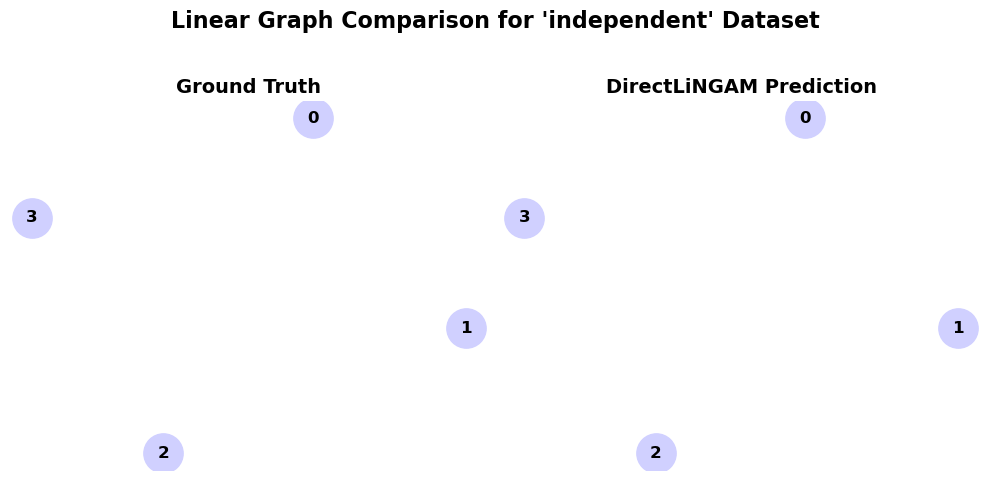

  Data Case: 'chain' => SHD: 0.0, F1-Score: 1.00


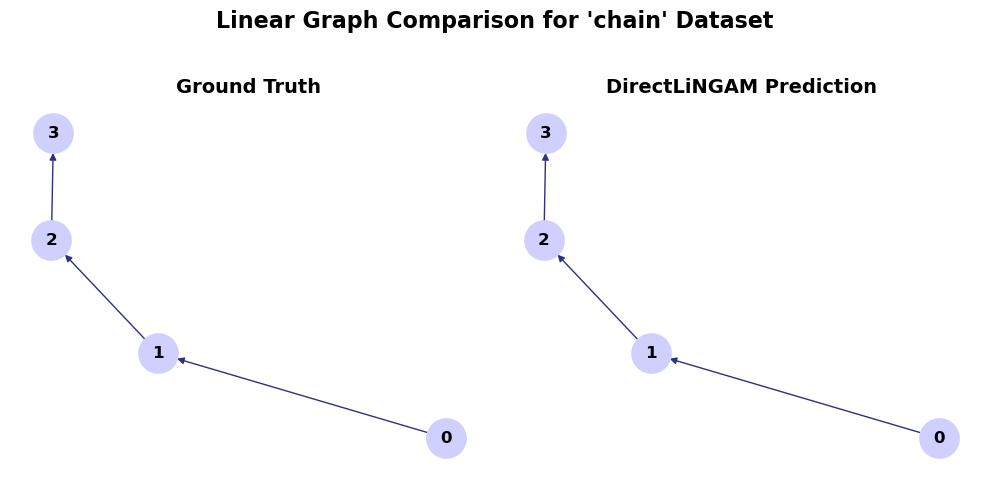

  Data Case: 'mixed' => SHD: 0.0, F1-Score: 1.00


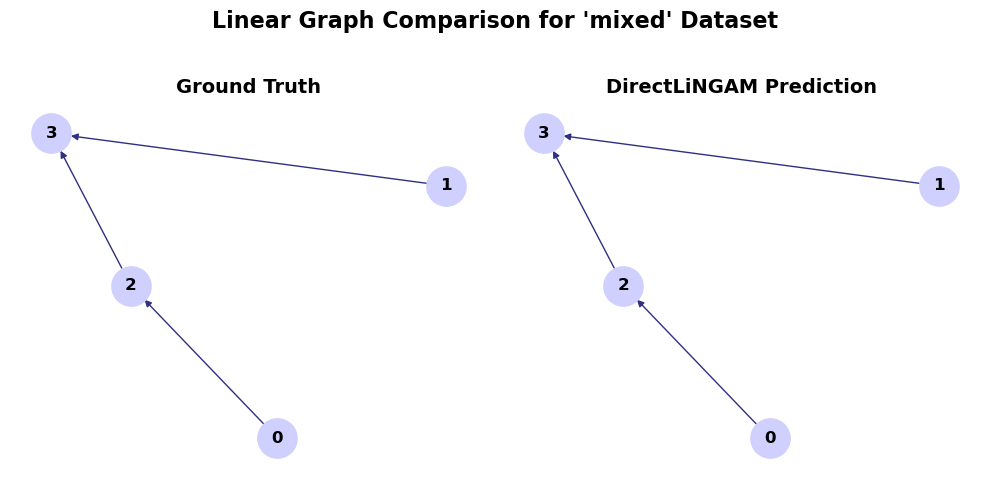


--- Linear Baseline Run 2/6 ---
  Data Case: 'independent' => SHD: 0.0, F1-Score: 0.00
  Data Case: 'chain' => SHD: 0.0, F1-Score: 1.00
  Data Case: 'mixed' => SHD: 0.0, F1-Score: 1.00

--- Linear Baseline Run 3/6 ---
  Data Case: 'independent' => SHD: 0.0, F1-Score: 0.00
  Data Case: 'chain' => SHD: 0.0, F1-Score: 1.00
  Data Case: 'mixed' => SHD: 0.0, F1-Score: 1.00

--- Linear Baseline Run 4/6 ---
  Data Case: 'independent' => SHD: 0.0, F1-Score: 0.00
  Data Case: 'chain' => SHD: 0.0, F1-Score: 1.00
  Data Case: 'mixed' => SHD: 0.0, F1-Score: 1.00

--- Linear Baseline Run 5/6 ---
  Data Case: 'independent' => SHD: 0.0, F1-Score: 0.00
  Data Case: 'chain' => SHD: 0.0, F1-Score: 1.00
  Data Case: 'mixed' => SHD: 0.0, F1-Score: 1.00

--- Linear Baseline Run 6/6 ---
  Data Case: 'independent' => SHD: 0.0, F1-Score: 0.00
  Data Case: 'chain' => SHD: 0.0, F1-Score: 1.00
  Data Case: 'mixed' => SHD: 0.0, F1-Score: 1.00

--- FINAL LINEAR BASELINE RESULTS ---
          independent  chain  m

In [7]:
evaluate_linear_baseline(n_runs=6, n_features=4)


========================= EVALUATION RUN 1/3 =========================

--- Data Case: 'independent' ---
Running NL-HGR Model...


c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib

  NL-HGR Result => F1-Score: 0.00
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.00
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.00


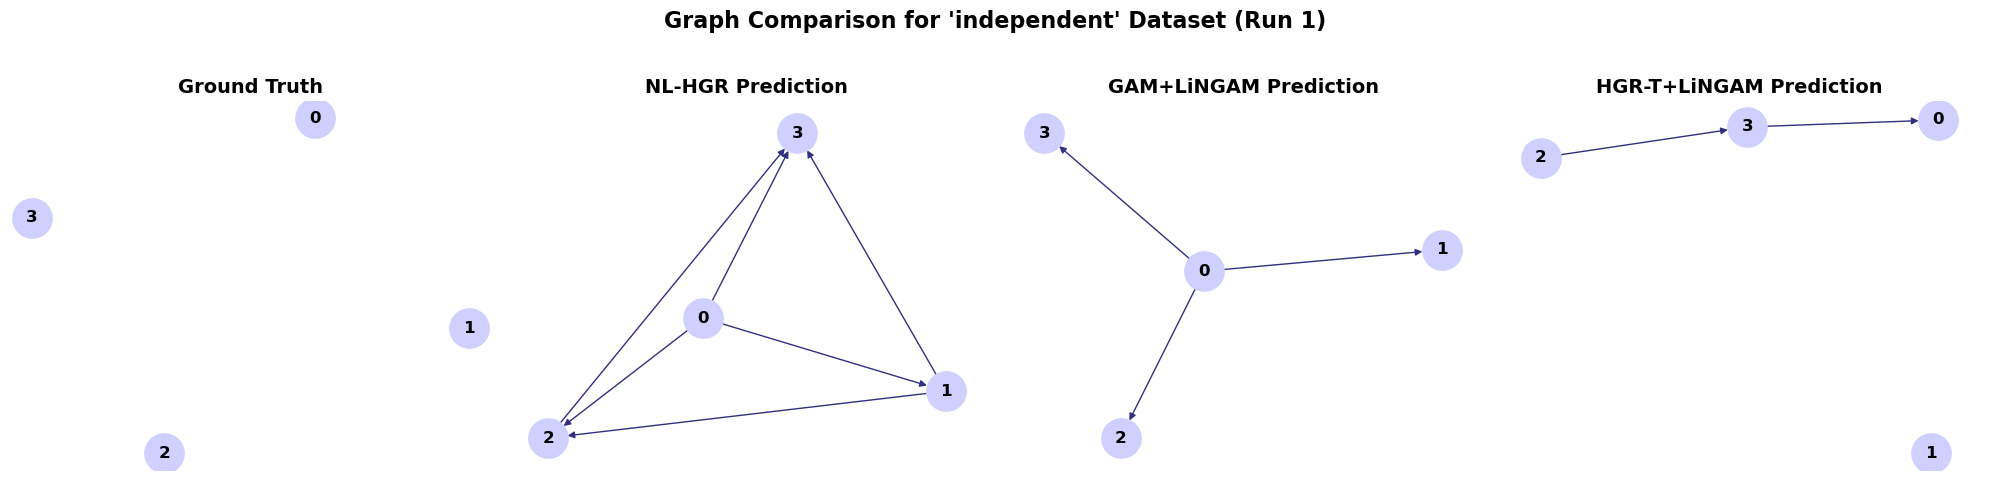


--- Data Case: 'cubic_sine' ---
Running NL-HGR Model...


c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib

  NL-HGR Result => F1-Score: 0.22
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.22
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.22


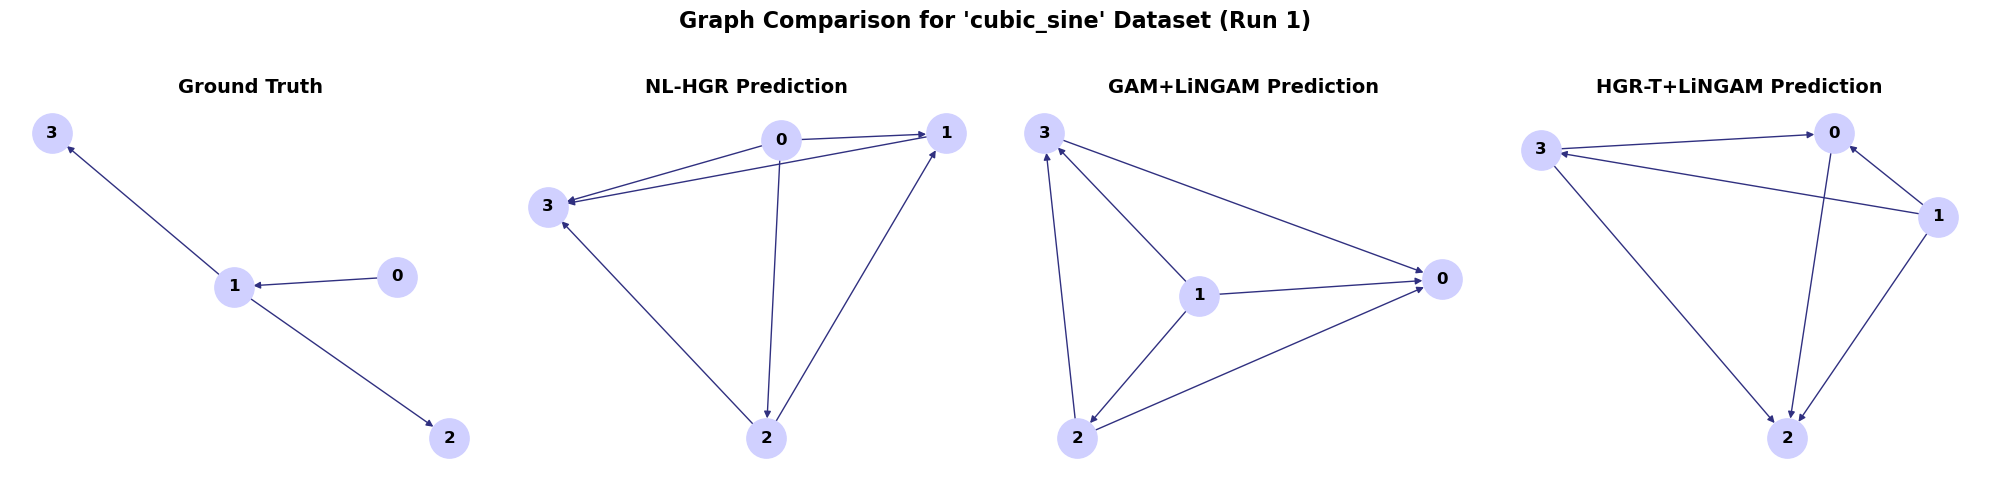


--- Data Case: 'mixed_root' ---
Running NL-HGR Model...


c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib

  NL-HGR Result => F1-Score: 0.44
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.29
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.22


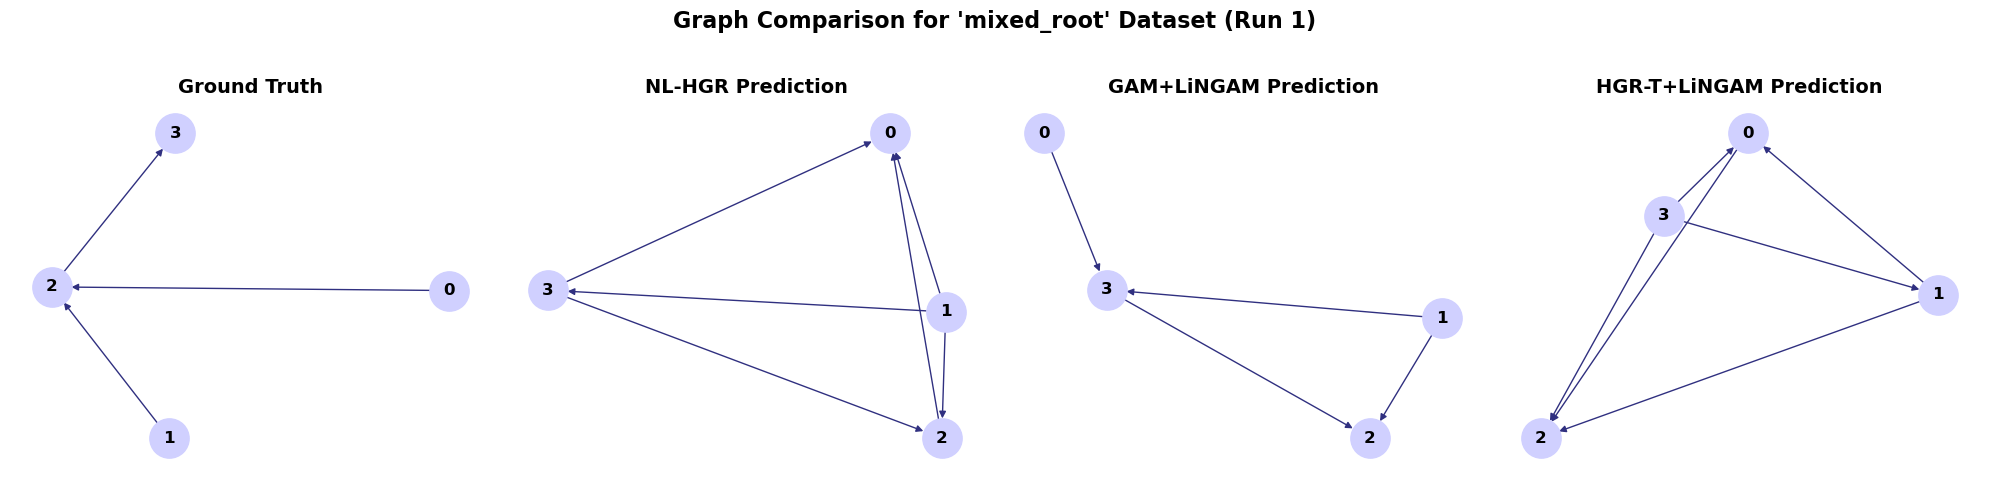


--- Data Case: 'diamond' ---
Running NL-HGR Model...


c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib

  NL-HGR Result => F1-Score: 0.40
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.33
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.60


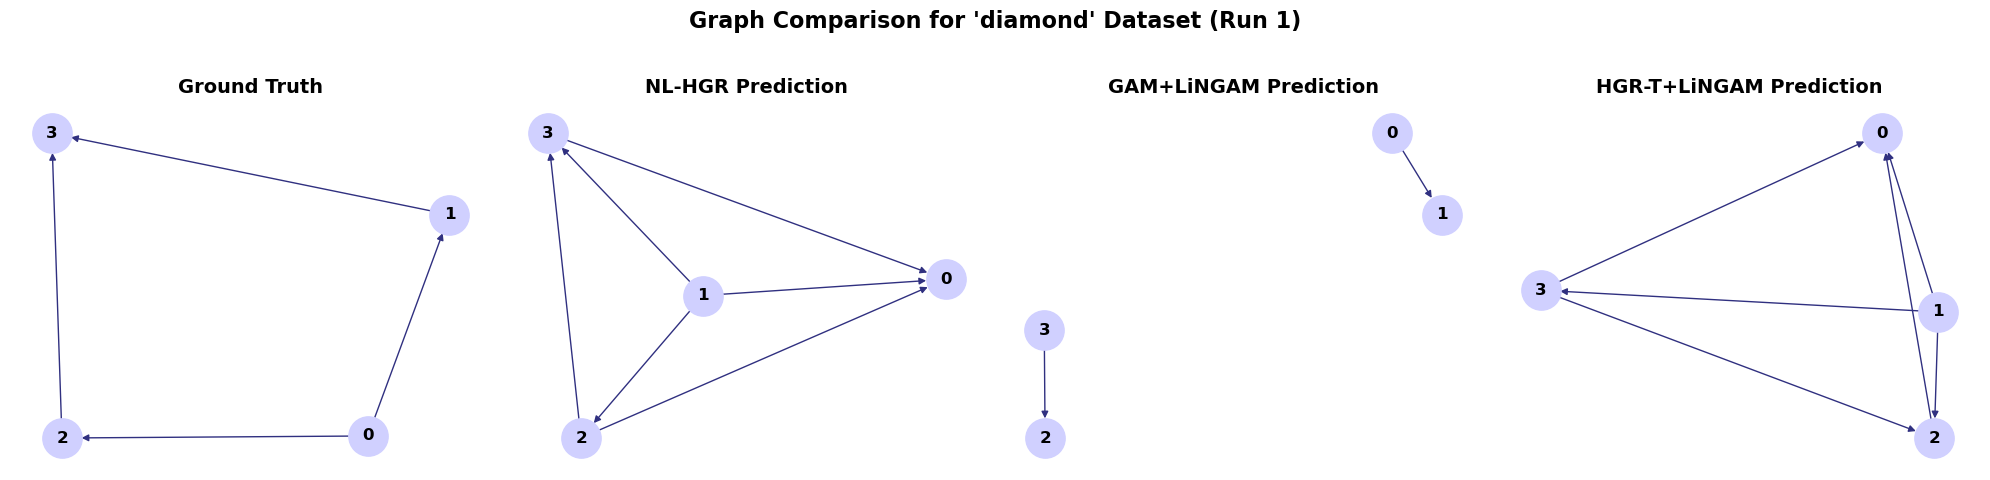


--- Data Case: 'interaction' ---
Running NL-HGR Model...


c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib

  NL-HGR Result => F1-Score: 0.44
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.25
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.00


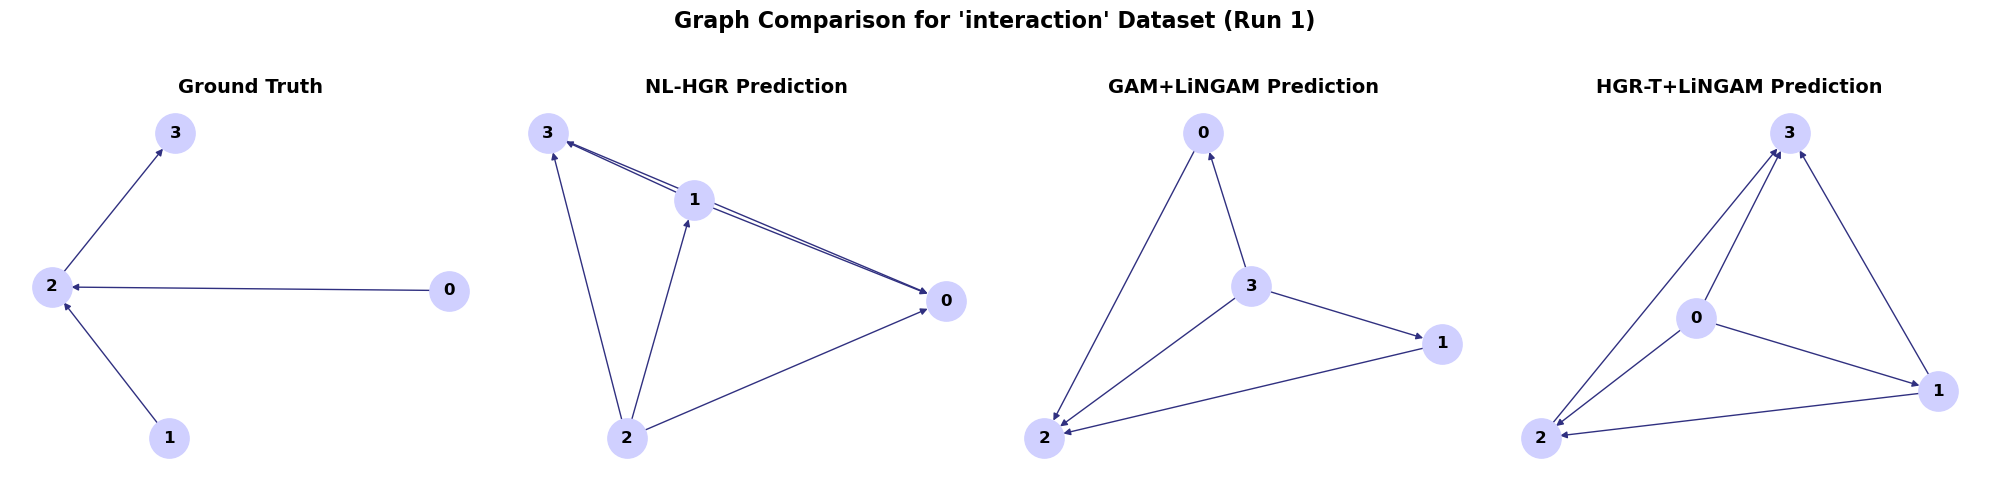


========================= EVALUATION RUN 2/3 =========================

--- Data Case: 'independent' ---
Running NL-HGR Model...


c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib

  NL-HGR Result => F1-Score: 0.00
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.00
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.00

--- Data Case: 'cubic_sine' ---
Running NL-HGR Model...


c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib

  NL-HGR Result => F1-Score: 0.44
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.22
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.75

--- Data Case: 'mixed_root' ---
Running NL-HGR Model...


...

  NL-HGR Result => F1-Score: 0.60
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.33
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.00

--- Data Case: 'interaction' ---
Running NL-HGR Model...


c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\PADIDAR\anaconda3\Lib

  NL-HGR Result => F1-Score: 0.00
Running GAM+LiNGAM Model...
  GAM+LiNGAM Result => F1-Score: 0.25
Running HGR-T+LiNGAM Model...
  HGR-T+LiNGAM Result => F1-Score: 0.22


========================= FINAL AGGREGATE RESULTS (3 RUNS) =========================

--- Model: NL-HGR ---
                independent  cubic_sine  mixed_root  diamond  interaction
Avg. Shd                6.0        6.33        6.33     5.33         6.33
Avg. F1                 0.0        0.30        0.30     0.47         0.30
Avg. Precision          0.0        0.22        0.22     0.39         0.22
Avg. Recall             0.0        0.44        0.44     0.58         0.44

--- Model: GAM+LiNGAM ---
                independent  cubic_sine  mixed_root  diamond  interaction
Avg. Shd               2.33        7.00        4.67     4.00         5.33
Avg. F1                0.00        0.22        0.41     0.33         0.28
Avg. Precision         0.00        0.17        0.33     0.50         0.24
Avg. Recall            0.00

c:\Users\PADIDAR\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\PADIDAR\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\PADIDAR\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\PADIDAR\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\PADIDAR\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\PADIDAR\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount

                independent  cubic_sine  mixed_root  diamond  interaction
Avg. Shd               4.33        4.00        6.33     7.67         7.67
Avg. F1                0.00        0.55        0.30     0.20         0.15
Avg. Precision         0.00        0.42        0.22     0.17         0.11
Avg. Recall            0.00        0.78        0.44     0.25         0.22


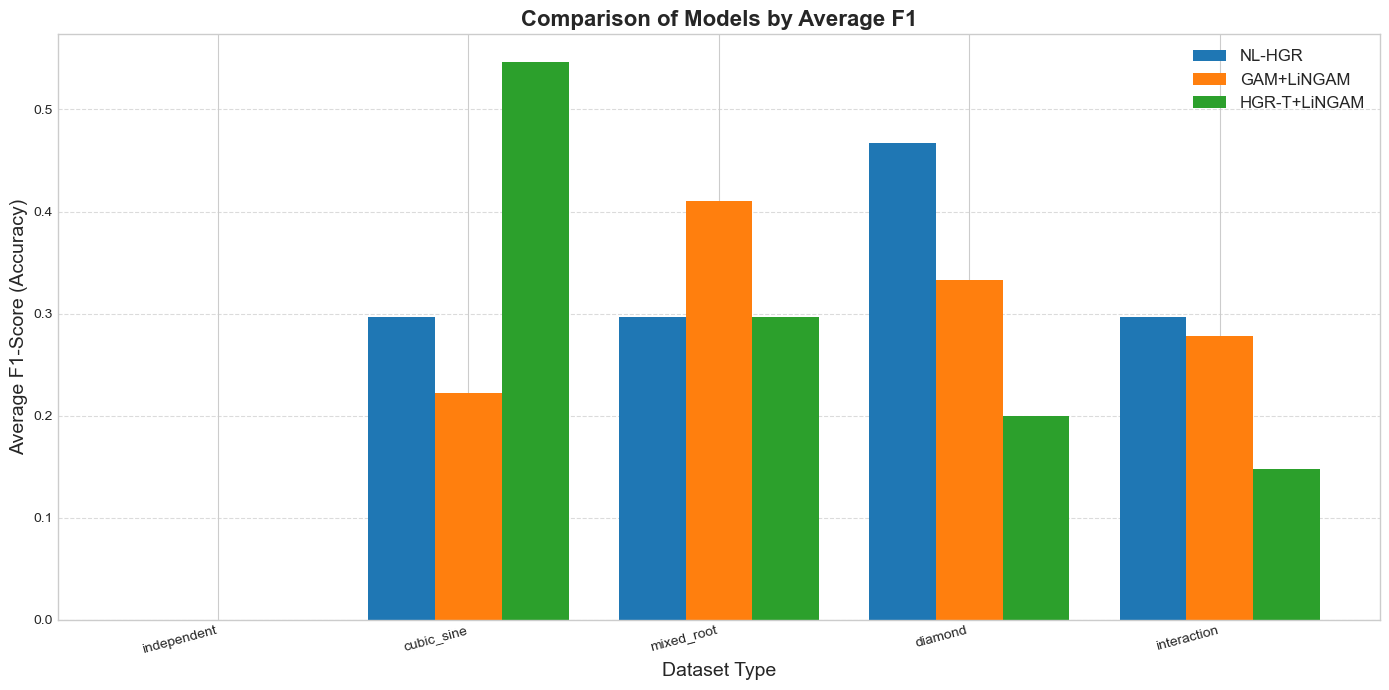

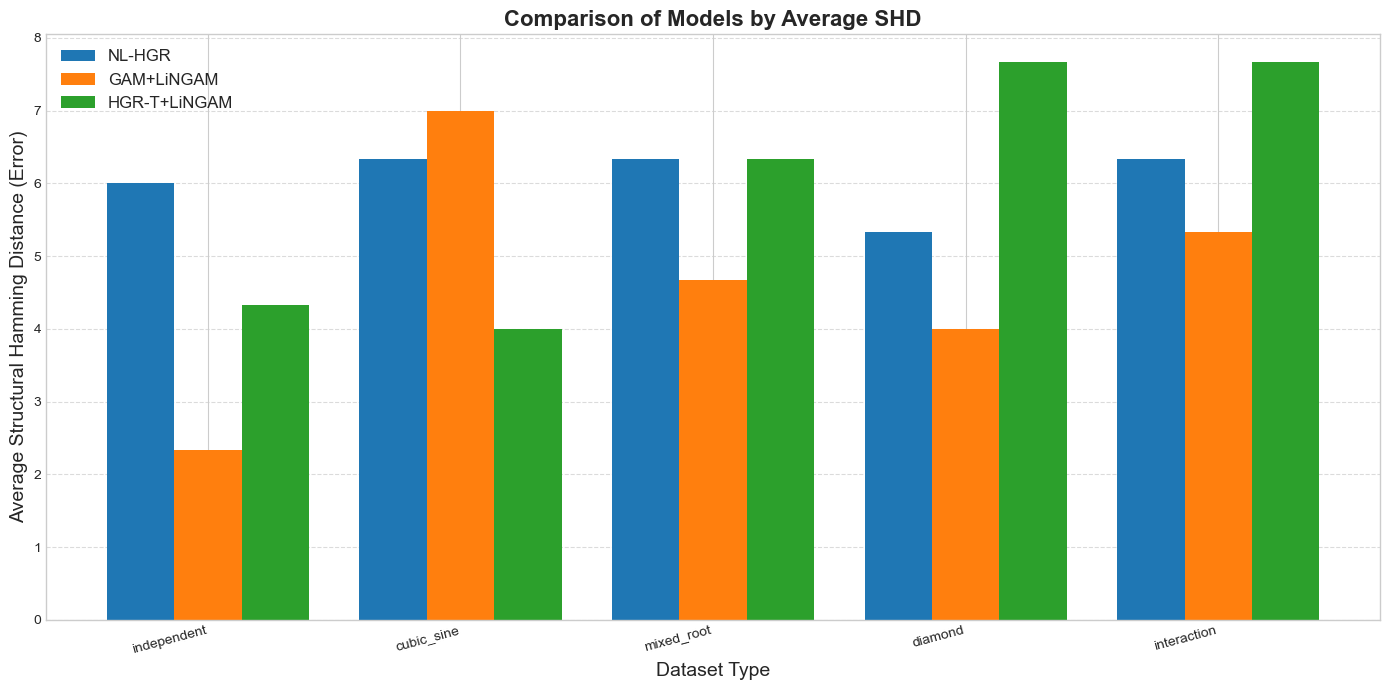

In [8]:
run_comparative_evaluation(n_runs=3, n_features=4)